# GCC Equity Markets: MSCI Inclusion Impact & Upgrade Opportunities

---
title: "GCC Equity Markets: MSCI Inclusion Impact & Upgrade Opportunities"
date: 2026-06-15
description: "This is model contains all the major quantitative calculations supporting the research report on MSCI index reclassification and its impact on GCC equity markets. It follows the presentation section order."
image: images/non oil thumbnail.png
categories: [Quantitative Research]
---

**Three analytical sections:**

1. **Historical Impact Analysis**: Event-study framework: UAE (2014), Qatar (2014), Saudi Arabia (2019)
2. **Size & Liquidity Screening**:ATVR and market cap vs MSCI EM entry thresholds
3. **Equity Market Performance**:Returns, risk, and diversification metrics

**Data sources:** Investing.com (index and stock price/volume), MSCI factsheets (float market caps), MSCI Global Investable Market Indexes Methodology (thresholds)

> **Note:** All file paths are hidden for privacy as they point to my local data files. Update `OUTPUT_PATH`, `base_path`, and CSV paths to match your directory before running.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from IPython.display import display

# ── Notebook display settings ──────────────────────────────────────────────
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

# ── Chart style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    11,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

# ── Colour palette for the four event-study windows ───────────────────────
WINDOW_COLORS = {
    'Pre-Announcement': '#4A4A6A',
    'Early Transition': '#1F6FEB',
    'Late Transition':  '#F4A261',
    'Post-Inclusion':   '#2A9D8F',
}

## Section 1 — Historical Impact Analysis

Applies an event-study framework to the three GCC markets that have completed a Frontier → Emerging Market reclassification: UAE (2014), Qatar (2014), and Saudi Arabia (2019). Kuwait's 2020 upgrade is excluded, its transition coincided with the COVID-19 crash, making it impossible to isolate MSCI-driven effects.

Each case is anchored on two dates: the **announcement date** (MSCI public confirmation) and the **effective inclusion date** (market enters the index). Four 126-trading-day windows are sliced around these anchors and four transmission channels are measured across each window.

> **Window length:** 126 trading days = 6 calendar months. All four windows use the same length for comparability.

### 1.1 Data Cleaning Function

In [2]:
# ── CLEANING FUNCTION ─────────────────────────────────────────────────────
# Resolves consistent Investing.com export quirks:
#   - Dates as strings:     '02/26/2015'
#   - Prices with commas:   '4,686.19'
#   - Volume with suffixes: '62.82M' or '1.2B'
# Output: clean dataframe with Date, return, and Vol. columns

def clean_investing_csv(df, keep_ohlc=False, keep_price=False):
    df = df.copy()

    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df = df.sort_values('Date').reset_index(drop=True)

    df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)

    if keep_ohlc:
        for col in ['Open', 'High', 'Low']:
            df[col] = df[col].astype(str).str.replace(',', '').astype(float)

    def parse_volume(v):
        v = str(v).strip().replace(',', '')
        if v.endswith('B'):   return float(v[:-1]) * 1_000_000_000
        elif v.endswith('M'): return float(v[:-1]) * 1_000_000
        elif v.endswith('K'): return float(v[:-1]) * 1_000
        else:
            try:    return float(v)
            except: return np.nan

    df['Vol.']   = df['Vol.'].apply(parse_volume)
    df['return'] = df['Price'].pct_change()

    cols = ['Date', 'return', 'Vol.']
    if keep_price: cols.append('Price')
    if keep_ohlc:  cols += ['Open', 'High', 'Low']

    return df[cols].copy()

### 1.2 Load & Clean Data — UAE

In [3]:
# ── UAE: TWO EXCHANGES, ONE COMBINED INDEX ────────────────────────────────
# UAE has two major exchanges: ADX (Abu Dhabi) and DFM (Dubai).
# MSCI included both in the 2014 upgrade. Weights (70% ADX / 30% DFM)
# I approximate their relative market cap at the time of reclassification.

uae_adx = clean_investing_csv(
    pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\FTSE ADX General Historical Data.csv'),
    keep_price=True
)
uae_dfm = clean_investing_csv(
    pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\DFM General Historical Data.csv'),
    keep_price=True
)

uae = pd.merge(
    uae_adx[['Date', 'Price', 'return', 'Vol.']],
    uae_dfm[['Date', 'Price', 'return', 'Vol.']],
    on='Date', suffixes=('_adx', '_dfm')
)

ADX_WEIGHT = 0.70
DFM_WEIGHT = 0.30

uae['return'] = (ADX_WEIGHT * uae['return_adx']) + (DFM_WEIGHT * uae['return_dfm'])
uae['Vol.']   = uae['Vol._adx'] + uae['Vol._dfm']
# Reconstruct a synthetic price index from the combined return series
uae['Price']  = 1000 * np.exp(uae['return'].cumsum())

uae_combined = uae[['Date', 'return', 'Vol.', 'Price']].dropna().reset_index(drop=True)

print(f'UAE combined: {len(uae_combined):,} trading days')
print(f'Date range:   {uae_combined["Date"].min().date()} to {uae_combined["Date"].max().date()}')

UAE combined: 748 trading days
Date range:   2012-03-04 to 2015-02-26


### 1.3 Load & Clean Data — Qatar, Saudi Arabia, MSCI EM

In [4]:
# ── SINGLE-INDEX COUNTRIES + MSCI EM BENCHMARK ───────────────────────────
# Qatar and Saudi Arabia are single-exchange markets, no combining needed.
# MSCI EM is the benchmark for computing rolling correlation in Section 1.5.

qatar   = clean_investing_csv(pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\QE All Shares Historical Data.csv'))
saudi   = clean_investing_csv(pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\Tadawul All Share Historical Data.csv'))
msci_em = clean_investing_csv(pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\MSCI Emerging Markets Historical Data.csv'))

print(f'Qatar:   {len(qatar):,} days | {qatar["Date"].min().date()} to {qatar["Date"].max().date()}')
print(f'Saudi:   {len(saudi):,} days | {saudi["Date"].min().date()} to {saudi["Date"].max().date()}')
print(f'MSCI EM: {len(msci_em):,} days | {msci_em["Date"].min().date()} to {msci_em["Date"].max().date()}')

Qatar:   744 days | 2012-03-01 to 2015-02-26
Saudi:   684 days | 2017-09-06 to 2020-05-31
MSCI EM: 2,329 days | 2012-01-30 to 2020-12-31


### 1.4 Event Study Configuration

The `events` dictionary stores three things for each country: the index data, the announcement date, and the inclusion date.

These two dates are kept separate because they trigger different market behaviour:

- **Announcement date**: The day MSCI confirms the upgrade. Active fund managers start buying here in anticipation of future passive flows.
- **Inclusion date**: The day the market officially enters the index. Passive funds are forced to buy on this date to match their benchmark weights.

Keeping them separate is what allows the four windows to isolate different effects.

In [6]:
# ── EVENT STUDY CONFIGURATION ─────────────────────────────────────────────

# 126 trading days = approximately 6 calendar months
WINDOW = 126

# Update to your local output directory
OUTPUT_PATH = r"C:\Users\USER\Desktop\Arqaam_Intern_Case\\"

events = {
    'UAE': {
        'df':           uae_combined,
        'announcement': pd.Timestamp('2013-06-11'),   # MSCI announcement
        'inclusion':    pd.Timestamp('2014-05-31'),   # Effective index entry
    },
    'Qatar': {
        'df':           qatar,
        'announcement': pd.Timestamp('2013-06-11'),
        'inclusion':    pd.Timestamp('2014-05-31'),
    },
    'Saudi': {
        'df':           saudi,
        'announcement': pd.Timestamp('2018-06-20'),
        'inclusion':    pd.Timestamp('2019-05-28'),
    },
}

### 1.5 Analytical Functions

Four functions form the engine of the event study. Defined separately so each can be read and verified in isolation before the main loop runs them in sequence.

In [7]:
# ── WINDOW SLICER ─────────────────────────────────────────────────────────
# Locates announcement and inclusion dates by index position, then slices
# four equal WINDOW-length windows around each anchor date.
#
# Window 1 — Pre-Announcement  : 126 days before the announcement date  (baseline)
# Window 2 — Early Transition  : 126 days after the announcement date   (active repositioning)
# Window 3 — Late Transition   : 126 days before the inclusion date     (passive front-running)
# Window 4 — Post-Inclusion    : 126 days after the inclusion date      (effects sustained or reversed)
#
# Windows 2 and 3 may overlap when announcement-to-inclusion gap < WINDOW.
# This is by design — they measure different investor behaviours.

def get_windows(df, ann, inc, window):
    ann_idx = df[df['Date'] >= ann].index[0]
    inc_idx = df[df['Date'] >= inc].index[0]

    pre         = df.iloc[ann_idx - window : ann_idx].copy()
    early_trans = df.iloc[ann_idx           : ann_idx + window].copy()
    late_trans  = df.iloc[inc_idx - window  : inc_idx].copy()
    post        = df.iloc[inc_idx           : inc_idx + window].copy()

    return {
        'Pre-Announcement': pre,
        'Early Transition': early_trans,
        'Late Transition':  late_trans,
        'Post-Inclusion':   post,
    }

In [8]:
# ── ROLLING CORRELATION — PRECOMPUTE ON FULL DATASET ──────────────────────
# Must be calculated BEFORE window slicing. If calculated per window, the
# first 60 rows of each window produce NaN because the rolling lookback has
# no prior history. Running on the full series first avoids this distortion.

def precompute_rolling_corr(df, msci_em, window=60):
    merged = pd.merge(
        df[['Date', 'return']],
        msci_em[['Date', 'return']].rename(columns={'return': 'msci_return'}),
        on='Date', how='inner'
    )
    # 60-day rolling Pearson correlation: country daily returns vs MSCI EM daily returns
    merged['Rolling_Corr_60d'] = merged['return'].rolling(window).corr(merged['msci_return'])
    return merged[['Date', 'Rolling_Corr_60d']]

In [9]:
# ── METRIC CALCULATIONS ───────────────────────────────────────────────────
# Computes all four transmission channel metrics per window.
# Returns a tidy DataFrame with one row per window.
#
# Ch.1 Price:       Cumulative simple return (compounded daily)
# Ch.2 Liquidity:   Avg daily share volume; uplift vs pre-announcement baseline
# Ch.3 Volatility:  Daily return std x sqrt(252) => annualised
# Ch.4 Correlation: Avg 60-day rolling correlation with MSCI EM within window

def calc_metrics(windows, corr_series):
    results     = {}
    pre_avg_vol = windows['Pre-Announcement']['Vol.'].mean()

    for window_name, df in windows.items():

        cum_return_pct = round(((1 + df['return']).prod() - 1) * 100, 2)

        avg_daily_vol  = df['Vol.'].mean()
        vol_uplift_pct = round(((avg_daily_vol / pre_avg_vol) - 1) * 100, 2)

        ann_vol_pct = round(df['return'].std() * np.sqrt(252) * 100, 2)

        window_corr = corr_series[
            (corr_series['Date'] >= df['Date'].min()) &
            (corr_series['Date'] <= df['Date'].max())
        ]['Rolling_Corr_60d'].dropna()
        avg_corr = round(window_corr.mean(), 3)

        results[window_name] = {
            'Cumulative Return (%)':        cum_return_pct,
            'Avg Daily Volume':             round(avg_daily_vol, 2),
            'Volume Uplift vs Pre-Ann (%)': vol_uplift_pct,
            'Annualised Volatility (%)':    ann_vol_pct,
            'Avg Rolling Correlation':      avg_corr,
        }

    return pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Window'})

In [10]:
# ── ROLLING CORRELATION SERIES — FULL STUDY PERIOD ────────────────────────
# Extracts the correlation time series spanning the full study window.
# Tags each row with its window label and adds event date markers
# used for chart vertical reference lines.

def calc_rolling_corr_series(corr_series, df, ann, inc, window):
    ann_idx = df[df['Date'] >= ann].index[0]
    inc_idx = df[df['Date'] >= inc].index[0]

    start_date = df.iloc[ann_idx - window]['Date']
    end_date   = df.iloc[min(inc_idx + window, len(df) - 1)]['Date']

    result = corr_series[
        (corr_series['Date'] >= start_date) &
        (corr_series['Date'] <= end_date)
    ].copy()

    def tag_window(date):
        if date < ann:                              return 'Pre-Announcement'
        elif date < ann + pd.DateOffset(months=6): return 'Early Transition'
        elif date < inc:                            return 'Late Transition'
        else:                                       return 'Post-Inclusion'

    result['Window']            = result['Date'].apply(tag_window)
    result['Announcement_Date'] = ann
    result['Inclusion_Date']    = inc

    return result[['Date', 'Rolling_Corr_60d', 'Window', 'Announcement_Date', 'Inclusion_Date']]

### 1.6 Results — Four Transmission Channels

Each channel is calculated separately across all three countries and saved to Excel for chart building.

**Price Performance**: Cumulative return per window, re-indexed to 100 at the start so returns are comparable regardless of starting price level. The full announcement-to-inclusion return is also calculated by slicing directly between the two anchor dates, capturing the total transition period as a single number.

**Liquidity**: Average daily share volume per window measured as a % change vs the pre-announcement baseline. This isolates upgrade-driven trading activity from normal market variation.

**Volatility**: Annualised volatility per window, calculated as daily return standard deviation × √252. Comparing across windows shows whether the upgrade process introduced uncertainty into the market or whether conditions stabilised over time.

**Correlation**: 60-day rolling correlation with MSCI EM per window. Correlation is precomputed on the full dataset before slicing into windows to avoid NaN distortion that would appear if calculated on each window independently.

In [ ]:
# ── CHANNEL 1: PRICE PERFORMANCE ──────────────────────────────────────────

for country, config in events.items():
    df  = config['df'].copy().reset_index(drop=True)
    ann = config['announcement']
    inc = config['inclusion']

    windows = get_windows(df, ann, inc, WINDOW)

    # Build day-by-day indexed price path for each window
    price_rows = []
    for window_name, wdf in windows.items():
        wdf = wdf.copy().reset_index(drop=True)
        wdf['Indexed_Price'] = 100 * (1 + wdf['return']).cumprod()
        wdf.loc[wdf.index[0], 'Indexed_Price'] = 100
        wdf['Window'] = window_name
        wdf['Day']    = range(1, len(wdf) + 1)
        price_rows.append(wdf[['Day', 'Window', 'Indexed_Price', 'Date']])

    price_df = pd.concat(price_rows, ignore_index=True)

    # Announcement-to-inclusion return: slice raw data between the two dates
    transition = df[(df['Date'] >= ann) & (df['Date'] < inc)].copy()
    ann_to_inc = round(((1 + transition['return']).prod() - 1) * 100, 2)

    # Display summary
    print(f'\n{country}  |  Announcement: {ann.date()}  |  Inclusion: {inc.date()}')
    summary = (
        price_df.groupby('Window')['Indexed_Price']
        .last().sub(100)
        .rename('Cumulative Return (%)')
        .reindex(['Pre-Announcement', 'Early Transition', 'Late Transition', 'Post-Inclusion'])
        .to_frame()
    )
    display(summary.style.format('{:+.2f}%'))
    print(f'  Announcement to Inclusion (full period): {ann_to_inc:+.2f}%')

    # Save day-by-day indexed price data to Excel for chart building
    price_df.to_excel(f'{OUTPUT_PATH}{country}_Price.xlsx', index=False)
    print(f'  {country}_Price.xlsx saved')


UAE  |  Announcement: 2013-06-11  |  Inclusion: 2014-05-31


,Cumulative Return (%)
Window,
Pre-Announcement,+39.44%
Early Transition,+19.70%
Late Transition,+46.72%
Post-Inclusion,-12.30%


  Announcement to Inclusion (full period): +66.30%
  UAE_Price.xlsx saved

Qatar  |  Announcement: 2013-06-11  |  Inclusion: 2014-05-31


,Cumulative Return (%)
Window,
Pre-Announcement,+18.08%
Early Transition,+10.12%
Late Transition,+32.66%
Post-Inclusion,-4.94%


  Announcement to Inclusion (full period): +44.41%
  Qatar_Price.xlsx saved

Saudi  |  Announcement: 2018-06-20  |  Inclusion: 2019-05-28


,Cumulative Return (%)
Window,
Pre-Announcement,+15.00%
Early Transition,-6.53%
Late Transition,+6.84%
Post-Inclusion,-6.09%


  Announcement to Inclusion (full period): +1.35%
  Saudi_Price.xlsx saved


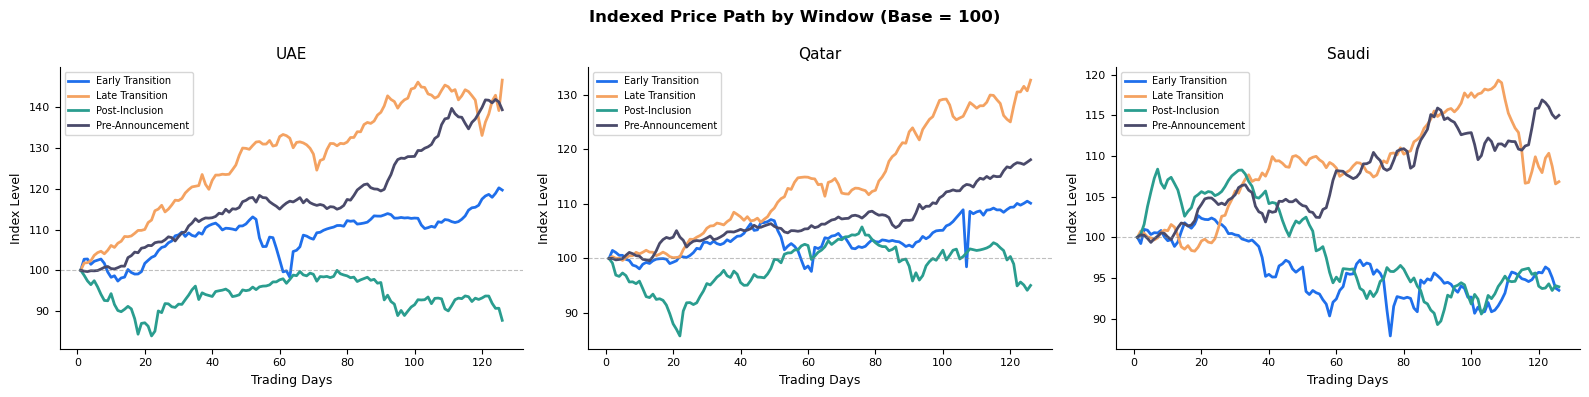

In [20]:
# ── PLOT: INDEXED PRICE PATH ───────────────────────────────────────────────
# One subplot per country, four lines per chart — one per window.
# Reads from the saved Excel files so this cell can be run independently.

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
fig.suptitle('Indexed Price Path by Window (Base = 100)', fontsize=12, fontweight='bold')

for ax, country in zip(axes, events.keys()):
    df_plot = pd.read_excel(f'{OUTPUT_PATH}{country}_Price.xlsx')

    for window_name, group in df_plot.groupby('Window'):
        ax.plot(group['Day'].values, group['Indexed_Price'].values,
                label=window_name, color=WINDOW_COLORS[window_name], linewidth=2)

    ax.axhline(100, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(country)
    ax.set_xlabel('Trading Days')
    ax.set_ylabel('Index Level')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# ── CHANNEL 2: LIQUIDITY ───────────────────────────────────────────────────

for country, config in events.items():
    df  = config['df'].copy().reset_index(drop=True)
    ann = config['announcement']
    inc = config['inclusion']

    windows  = get_windows(df, ann, inc, WINDOW)
    pre_avg  = windows['Pre-Announcement']['Vol.'].mean()

    # Build day-by-day volume data with uplift vs pre-announcement baseline
    vol_rows = []
    for window_name, wdf in windows.items():
        wdf = wdf.copy().reset_index(drop=True)
        wdf['Window']            = window_name
        wdf['Avg_Daily_Volume']  = wdf['Vol.'].mean()
        wdf['Volume_Uplift_Pct'] = round(((wdf['Vol.'].mean() / pre_avg) - 1) * 100, 2)
        vol_rows.append(wdf[['Date', 'Window', 'Vol.', 'Avg_Daily_Volume', 'Volume_Uplift_Pct']])

    vol_df = pd.concat(vol_rows, ignore_index=True)

    # Display uplift summary
    print(f'\n{country}')
    summary = (
        vol_df.groupby('Window')[['Avg_Daily_Volume', 'Volume_Uplift_Pct']]
        .first()
        .reindex(['Pre-Announcement', 'Early Transition', 'Late Transition', 'Post-Inclusion'])
    )
    display(summary.style.format({'Avg_Daily_Volume': '{:,.0f}', 'Volume_Uplift_Pct': '{:+.2f}%'}))

    # Save day-by-day volume data to Excel for chart building
    vol_df.to_excel(f'{OUTPUT_PATH}{country}_Volume.xlsx', index=False)
    print(f'  {country}_Volume.xlsx saved')


UAE


,Avg_Daily_Volume,Volume_Uplift_Pct
Window,,
Pre-Announcement,"413,341,270",+0.00%
Early Transition,"682,655,238",+65.16%
Late Transition,"940,914,444",+127.64%
Post-Inclusion,"475,064,206",+14.93%


  UAE_Volume.xlsx saved

Qatar


,Avg_Daily_Volume,Volume_Uplift_Pct
Window,,
Pre-Announcement,"6,350,079",+0.00%
Early Transition,"8,460,880",+33.24%
Late Transition,"17,156,190",+170.17%
Post-Inclusion,"13,368,968",+110.53%


  Qatar_Volume.xlsx saved

Saudi


,Avg_Daily_Volume,Volume_Uplift_Pct
Window,,
Pre-Announcement,"179,019,921",+0.00%
Early Transition,"131,020,238",-26.81%
Late Transition,"123,473,571",-31.03%
Post-Inclusion,"129,542,698",-27.64%


  Saudi_Volume.xlsx saved


In [18]:
# ── CHANNEL 3: VOLATILITY ─────────────────────────────────────────────────

for country, config in events.items():
    df  = config['df'].copy().reset_index(drop=True)
    ann = config['announcement']
    inc = config['inclusion']

    windows = get_windows(df, ann, inc, WINDOW)

    # Calculate annualised volatility per window
    vol_rows = []
    for window_name, wdf in windows.items():
        ann_vol = round(wdf['return'].std() * np.sqrt(252) * 100, 2)
        vol_rows.append({
            'Window':                  window_name,
            'Annualised Volatility (%)': ann_vol
        })

    vol_df = pd.DataFrame(vol_rows).set_index('Window')
    vol_df = vol_df.reindex(['Pre-Announcement', 'Early Transition', 'Late Transition', 'Post-Inclusion'])

    # Display
    print(f'\n{country}')
    display(vol_df.style.format('{:.2f}%'))

    # Save to Excel
    vol_df.reset_index().to_excel(f'{OUTPUT_PATH}{country}_Volatility.xlsx', index=False)
    print(f'  {country}_Volatility.xlsx saved')


UAE


,Annualised Volatility (%)
Window,
Pre-Announcement,10.89%
Early Transition,17.78%
Late Transition,17.99%
Post-Inclusion,22.20%


  UAE_Volatility.xlsx saved

Qatar


,Annualised Volatility (%)
Window,
Pre-Announcement,7.34%
Early Transition,23.17%
Late Transition,11.90%
Post-Inclusion,17.86%


  Qatar_Volatility.xlsx saved

Saudi


,Annualised Volatility (%)
Window,
Pre-Announcement,11.24%
Early Transition,16.99%
Late Transition,12.30%
Post-Inclusion,15.10%


  Saudi_Volatility.xlsx saved


In [19]:
# ── CHANNEL 4: MARKET INTEGRATION ─────────────────────────────────────────

for country, config in events.items():
    df  = config['df'].copy().reset_index(drop=True)
    ann = config['announcement']
    inc = config['inclusion']

    # Precompute on full dataset first, then slice into windows
    corr_series = precompute_rolling_corr(df, msci_em)
    windows     = get_windows(df, ann, inc, WINDOW)

    # Average correlation per window
    corr_rows = []
    for window_name, wdf in windows.items():
        window_corr = corr_series[
            (corr_series['Date'] >= wdf['Date'].min()) &
            (corr_series['Date'] <= wdf['Date'].max())
        ]['Rolling_Corr_60d'].dropna()

        corr_rows.append({
            'Window':               window_name,
            'Avg Rolling Correlation': round(window_corr.mean(), 3)
        })

    corr_summary = pd.DataFrame(corr_rows).set_index('Window')
    corr_summary = corr_summary.reindex(['Pre-Announcement', 'Early Transition', 'Late Transition', 'Post-Inclusion'])

    # Full rolling correlation time series for chart building
    corr_plot = calc_rolling_corr_series(corr_series, df, ann, inc, WINDOW)

    # Display
    print(f'\n{country}')
    display(corr_summary.style.format('{:.3f}'))

    # Save full time series to Excel for line chart with event markers
    corr_plot.to_excel(f'{OUTPUT_PATH}{country}_Correlation.xlsx', index=False)
    print(f'  {country}_Correlation.xlsx saved')


UAE


,Avg Rolling Correlation
Window,
Pre-Announcement,0.253
Early Transition,0.262
Late Transition,0.205
Post-Inclusion,0.131


  UAE_Correlation.xlsx saved

Qatar


,Avg Rolling Correlation
Window,
Pre-Announcement,0.229
Early Transition,0.253
Late Transition,0.122
Post-Inclusion,0.147


  Qatar_Correlation.xlsx saved

Saudi


,Avg Rolling Correlation
Window,
Pre-Announcement,0.249
Early Transition,0.261
Late Transition,0.335
Post-Inclusion,0.356


  Saudi_Correlation.xlsx saved


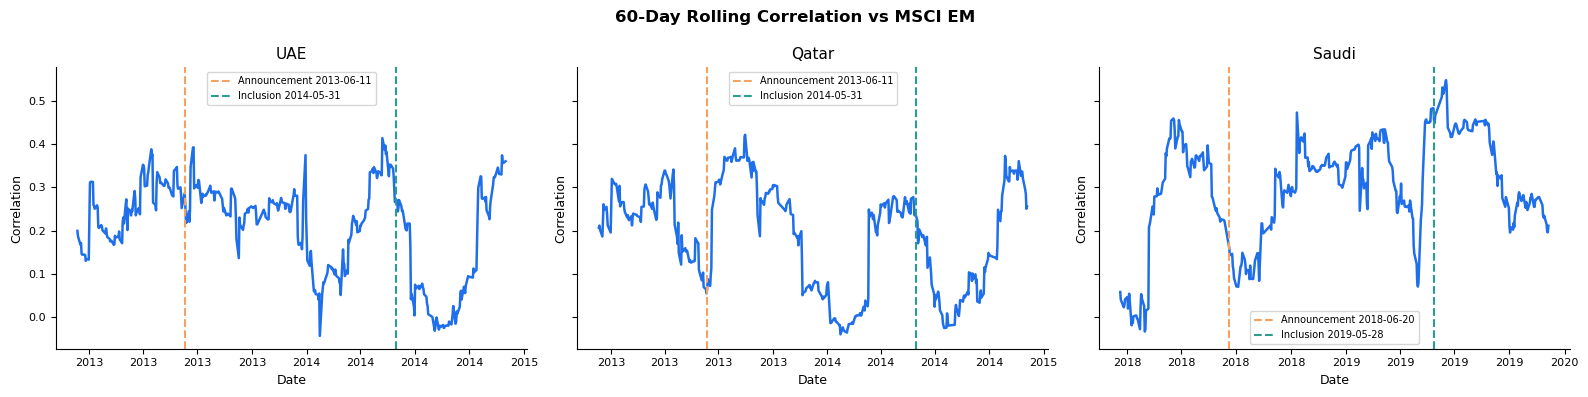

In [21]:
# ── PLOT: ROLLING CORRELATION VS MSCI EM ──────────────────────────────────
# One subplot per country showing the 60-day rolling correlation across
# the full study period. Vertical lines mark the announcement and
# inclusion dates so the shift in correlation can be read against each event.
# Reads from the saved Excel files so this cell can be run independently.

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle('60-Day Rolling Correlation vs MSCI EM', fontsize=12, fontweight='bold')

for ax, country in zip(axes, events.keys()):
    df_plot = pd.read_excel(f'{OUTPUT_PATH}{country}_Correlation.xlsx',
                            parse_dates=['Date', 'Announcement_Date', 'Inclusion_Date'])

    ann = df_plot['Announcement_Date'].iloc[0]
    inc = df_plot['Inclusion_Date'].iloc[0]

    ax.plot(df_plot['Date'], df_plot['Rolling_Corr_60d'],
            color='#1F6FEB', linewidth=1.8)
    ax.axvline(ann, color='#F4A261', linewidth=1.5, linestyle='--',
               label=f'Announcement {ann.date()}')
    ax.axvline(inc, color='#2A9D8F', linewidth=1.5, linestyle='--',
               label=f'Inclusion {inc.date()}')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_title(country)
    ax.set_xlabel('Date')
    ax.set_ylabel('Correlation')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Section 2 — Size & Liquidity Screening

MSCI EM entry requires at least **three qualifying securities** meeting all three thresholds simultaneously:

| Threshold | MSCI EM Requirement |
|---|---|
| Full Market Cap | ≥ USD 3,000mn |
| Float-Adjusted Market Cap | ≥ USD 1,900mn |
| ATVR | ≥ 15% |

The three stocks analysed are Bank Muscat, OQ E&P, and Sohar International, the top Omani constituents by float market cap per the latest MSCI factsheet.

ATVR is calculated as total 12-month traded value divided by the float-adjusted market cap, normalised to 261 trading days. Daily traded value is shares traded multiplied by closing price, converted from OMR/BHD/JOD to USD at the prevailing rate.

$$\text{ATVR} = \frac{\text{Total 12M Traded Value}}{\text{Float-Adjusted Market Cap}} \times \frac{261}{\text{Actual Trading Days}} \times 100$$

This is a simplified approximation of the official MSCI methodology, which uses monthly median daily traded values rather than total annual traded value. The denominator and direction are consistent with MSCI's approach and the results are directionally reliable for the purpose of this screening.

### 2.1 Configuration

In [51]:
# Each country has its own folder, FX rate, stock files, and float market caps
countries = {
    'Oman': {
        'base_path': r'C:\Users\USER\Desktop\Arqaam_Intern_Case\Oman',
        'fx_rate':   2.60,
        'files': {
            'Bank Muscat':         'Bank Muscat Stock Price History.csv',
            'Sohar International': 'Bank Sohar Stock Price History.csv',
            'OQ E&P':              'Oq Exploration and Production CJSC Stock Price History.csv',
        },
        'float_mktcap': {
            'Bank Muscat':         2_080_000_000,
            'Sohar International': 1_610_000_000,
            'OQ E&P':              1_990_000_000,
        },
    },
    'Bahrain': {
        'base_path': r'C:\Users\USER\Desktop\Arqaam_Intern_Case\Bahrain',
        'fx_rate':   2.66,  # BHD to USD
        'files': {
            'GFH Financial':  'GFH Financial BSC Stock Price History.csv',
            'Al-Salam Bank':  'Al Salam Bank Stock Price History.csv',
            'BBK':            'BBK Stock Price History.csv',
        },
        'float_mktcap': {
            'GFH Financial':  1_620_000_000,
            'Al-Salam Bank':    730_000_000,
            'BBK':              680_000_000,
        },
    }
}

def parse_volume(v):
    v = str(v).strip()
    if v.endswith('M'):   return float(v[:-1]) * 1_000_000
    elif v.endswith('K'): return float(v[:-1]) * 1_000
    else:                 return float(v)

### 2.2 ATVR Calculator

In [52]:
def calculate_atvr(filepath, stock_name, float_cap_usd, fx_rate):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
    df['Date']   = pd.to_datetime(df['Date'])
    df['Price']  = pd.to_numeric(df['Price'], errors='coerce')
    df['Volume'] = df['Vol.'].apply(parse_volume)
    df = df.sort_values('Date').reset_index(drop=True)

    end_date   = df['Date'].max()
    start_date = end_date - pd.DateOffset(years=1)
    df_12m     = df[df['Date'] >= start_date].copy()

    df_12m['Traded_Value_USD'] = df_12m['Volume'] * df_12m['Price'] * fx_rate

    trading_days = len(df_12m)
    total_traded = df_12m['Traded_Value_USD'].sum()
    adtv         = total_traded / trading_days
    atvr         = (total_traded / float_cap_usd) * (261 / trading_days) * 100

    return {
        'Country':       None,  # filled in the loop below
        'Stock':         stock_name,
        'Period':        f"{df_12m['Date'].min().date()} to {df_12m['Date'].max().date()}",
        'Trading Days':  trading_days,
        'ADTV (USD mn)': round(adtv / 1e6, 2),
        'ATVR (%)':      round(atvr, 2),
    }

### 2.3 Run Screening

In [53]:
results = []

for country_name, config in countries.items():
    for stock_name, filename in config['files'].items():
        filepath = os.path.join(config['base_path'], filename)
        result   = calculate_atvr(
            filepath, stock_name,
            config['float_mktcap'][stock_name],
            config['fx_rate']
        )
        result['Country'] = country_name
        results.append(result)

df_atvr = pd.DataFrame(results)

for country_name, group in df_atvr.groupby('Country'):
    display(
        group.drop(columns='Country')
        .set_index('Stock').style
        .format({'ADTV (USD mn)': '{:.2f}', 'ATVR (%)': '{:.2f}'})
        .set_caption(f'{country_name} — ATVR Calculation (Most Recent 12 Months)')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '11px')]},
            {'selector': 'th',      'props': [('background-color', '#0A2342'), ('color', 'white'), ('font-size', '10px')]},
        ])
    )

,Period,Trading Days,ADTV (USD mn),ATVR (%)
Stock,,,,
GFH Financial,2025-03-12 to 2026-03-12,186,2.72,43.90
Al-Salam Bank,2025-03-12 to 2026-03-12,243,0.36,13.02
BBK,2025-03-10 to 2026-03-09,182,0.11,4.17


,Period,Trading Days,ADTV (USD mn),ATVR (%)
Stock,,,,
Bank Muscat,2025-03-12 to 2026-03-12,248,14.05,176.30
Sohar International,2025-03-12 to 2026-03-12,248,13.52,219.20
OQ E&P,2025-04-06 to 2026-03-31,246,11.39,149.45


## Section 3: Equity Market Performance Oman and Bahrain

Computes the performance and risk metrics feeding the Pillar 3 (Equity Market Attractiveness) analysis for both upgrade candidates. Weekly frequency is used as it is more appropriate than daily for Oman and Bahrain given thin daily trading and occasional session gaps.

**Metrics:** 1Y trailing return, 3Y trailing return, annualised volatility, Sharpe ratio (risk-free rate: 3.7% US 3M T-Bill as of march), correlation vs MSCI EM.

### 3.1 Data Cleaning Function

In [36]:
# ── PRICE SERIES CLEANER ──────────────────────────────────────────────────────
# Handles MSCI index data which uses 'Close' in some files and 'Price' in others.
# Accepts column names as parameters so one function covers both cases.

def clean_price_df(df, date_col, price_col, market_name, dayfirst=False):
    """Clean and rename a price series from an investing.com or MSCI export."""
    out = df[[date_col, price_col]].copy()
    out[date_col]  = pd.to_datetime(out[date_col], errors='coerce', dayfirst=dayfirst)
    out[price_col] = (
        out[price_col].astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    out[price_col] = pd.to_numeric(out[price_col], errors='coerce')
    out.columns    = ['Date', market_name]
    out = out.dropna().sort_values('Date').reset_index(drop=True)
    return out


### 3.2 Load, Clean & Merge

In [54]:
msm_raw = pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\Thesis\MSCI Oman Historical Data.csv')
bse_raw = pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\Thesis\MSCI Bahrain Index.csv')
em_raw  = pd.read_csv(r'C:\Users\USER\Desktop\Arqaam_Intern_Case\Thesis\MSCI Emerging Markets Historical Data (1).csv')

# Oman and MSCI EM use 'Price'; Bahrain uses 'Close'
msm_clean = clean_price_df(msm_raw, 'Date', 'Price', 'Oman')
bse_clean = clean_price_df(bse_raw, 'Date', 'Close', 'Bahrain')
em_clean  = clean_price_df(em_raw,  'Date', 'Price', 'MSCI EM')

# Outer merge — all dates retained, gaps filled in next step
df_prices = (
    msm_clean
    .merge(bse_clean, on='Date', how='outer')
    .merge(em_clean,  on='Date', how='outer')
    .sort_values('Date')
    .set_index('Date')
)

print(f'Merged price series: {len(df_prices):,} rows')
print(f'Date range: {df_prices.index.min().date()} to {df_prices.index.max().date()}')
print(f'Columns: {df_prices.columns.tolist()}')

Merged price series: 1,286 rows
Date range: 2021-12-01 to 2026-03-15
Columns: ['Oman', 'Bahrain', 'MSCI EM']


### 3.3 Resample to Weekly

In [55]:
# ── WEEKLY RESAMPLING ─────────────────────────────────────────────────────
# Resample to Friday close. Forward-fill after resampling to handle weeks
# where a market was closed but others were not — avoids spurious return
# spikes from gaps between stale prices.

weekly_prices  = df_prices.resample('W-FRI').last().ffill()
weekly_returns = weekly_prices.pct_change().dropna()

print(f'Weekly observations: {len(weekly_prices):,}')
print(f'Date range: {weekly_prices.index.min().date()} to {weekly_prices.index.max().date()}')

Weekly observations: 225
Date range: 2021-12-03 to 2026-03-20


### 3.4 Metric Functions

In [45]:
# Risk-free rate: 3.7% (US 3M T-Bill)
rf        = 0.037
weekly_rf = rf / 52

def trailing_return(price_series, years):
    """Total return over the trailing N-year window from the last available date."""
    end_date   = price_series.dropna().index.max()
    start_date = end_date - pd.DateOffset(years=years)
    window     = price_series.loc[price_series.index >= start_date].dropna()
    if len(window) < 2:
        return np.nan
    return (window.iloc[-1] / window.iloc[0]) - 1

def annualised_vol(return_series):
    """Annualised volatility from weekly returns, scaled by sqrt(52)."""
    return return_series.std() * np.sqrt(52)

def sharpe_ratio(return_series, annual_rf=0.037):
    """Annualised Sharpe ratio using weekly return series."""
    ann_return = return_series.mean() * 52
    ann_vol    = return_series.std()  * np.sqrt(52)
    if ann_vol == 0:
        return np.nan
    return (ann_return - annual_rf) / ann_vol


### 3.5 Summary Statistics

In [56]:
markets = ['Oman', 'Bahrain','MSCI EM']
summary_rows = []

for market in markets:
    price_s  = weekly_prices[market].dropna()
    return_s = weekly_returns[market].dropna()

    summary_rows.append({
        'Market':                 market.replace('_', ' '),
        '1Y Return':              trailing_return(price_s, 1),
        '3Y Return':              trailing_return(price_s, 3),
        'Annualised Volatility':  annualised_vol(return_s),
        'Sharpe Ratio':           sharpe_ratio(return_s, annual_rf=rf),
        'Correlation vs MSCI EM': return_s.corr(weekly_returns['MSCI EM']) if market != 'MSCI EM' else 1.0,
    })

perf_df = pd.DataFrame(summary_rows).set_index('Market')

display(
    perf_df.style
    .format({
        '1Y Return':              '{:+.1%}',
        '3Y Return':              '{:+.1%}',
        'Annualised Volatility':  '{:.1%}',
        'Sharpe Ratio':           '{:.2f}',
        'Correlation vs MSCI EM': '{:.2f}',
    })
    .set_caption('Equity Market Performance: Oman Vs Bahrain Vs MSCI EM')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '11px')]},
        {'selector': 'th',      'props': [('background-color', '#0A2342'), ('color', 'white'), ('font-size', '10px')]},
    ])
)

,1Y Return,3Y Return,Annualised Volatility,Sharpe Ratio,Correlation vs MSCI EM
Market,,,,,
Oman,+79.6%,+55.8%,12.8%,0.92,0.13
Bahrain,+17.8%,+35.9%,11.3%,0.56,0.15
MSCI EM,+29.9%,+51.2%,14.9%,0.72,1.00
